# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Lab assignment №1, part 2
## Gradient boosting on temporal data and feature importances

Today we will work with Gradient Boosting library. It is one of the most popular models these days that shows both great quality and performance.

Choises for library are:

* [LightGBM](https://github.com/Microsoft/LightGBM) by Microsoft. Handful and fast.
* [Catboost](https://github.com/catboost/catboost) by Yandex. Tuned to deal well with categorical features.
* [xgboost](https://github.com/dmlc/xgboost) by dlmc. The most famous framework which got very popular on kaggle.

**Dataset**

By default we will work with widely known [Human Actividy Recognition (HAR) dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones). Data is available at UCI repository.

There are available both raw and preprocessed datasets. This time we will use the preprocessed one.
Some simple preprocessing is done for you.

If you want more interpretable data, you can take [Wine quality dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) (see details below).

Your __ultimate target is to get familiar with one of the frameworks above__ and achieve at least 90% accuracy on test dataset and try to get some useful insights on the features the model paid attention to.

_Despite the main language of this notebook is English, feel free to write your thoughts in Russian._

## Part 0. Downloading and preprocessing

The preprocessing is done for you. Let's take a look at the data:

In [52]:
# Download and unpack dataset from UCI
# !wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
# !unzip -u "UCI HAR Dataset.zip" "UCI HAR Dataset/train/X_train.txt" "UCI HAR Dataset/train/y_train.txt" \
# "UCI HAR Dataset/test/X_test.txt" "UCI HAR Dataset/test/y_test.txt" "UCI HAR Dataset/activity_labels.txt"

In [53]:
import matplotlib.pyplot as plt
import numpy as np

In [54]:
X_train = np.genfromtxt("UCI HAR Dataset/train/X_train.txt")
y_train = np.genfromtxt("UCI HAR Dataset/train/y_train.txt")
print(f"Train set: {X_train.shape}, {y_train.shape}")

X_test = np.genfromtxt("UCI HAR Dataset/test/X_test.txt")
y_test = np.genfromtxt("UCI HAR Dataset/test/y_test.txt")
print(f"Test set: {X_test.shape}, {y_test.shape}")

n_features = X_train.shape[1]

Train set: (7352, 561), (7352,)
Test set: (2947, 561), (2947,)


In [55]:
activity_labels = {}
with open("UCI HAR Dataset/activity_labels.txt", "r") as file:
    for line in file:
        label, name = line.strip().split(" ")
        activity_labels[int(label)] = name

activity_labels

{1: 'WALKING',
 2: 'WALKING_UPSTAIRS',
 3: 'WALKING_DOWNSTAIRS',
 4: 'SITTING',
 5: 'STANDING',
 6: 'LAYING'}

Let's normalize data

In [56]:
data_mean = X_train.mean(axis=0)
data_std = X_train.std(axis=0)

X_train = (X_train - data_mean) / data_std
X_test = (X_test - data_mean) / data_std

The dataset has some duplicating features. Let's remove them

In [57]:
# fmt: off
duplicating_columns = (
    205, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 231, 244, 257, 507, 520, 533, 546,
)
# fmt: on

duplicating_mask = np.isin(range(n_features), duplicating_columns)

In [58]:
X_train_unique = X_train[:, ~duplicating_mask]
X_test_unique = X_test[:, ~duplicating_mask]

X_train_unique.shape, X_test_unique.shape

((7352, 540), (2947, 540))

PCA could be useful in this case. E.g.

In [59]:
from sklearn.decomposition import PCA

In [60]:
pca = PCA(0.99)

X_train_pca = pca.fit_transform(X_train_unique)
X_test_pca = pca.transform(X_test_unique)

X_train_pca.shape, X_test_pca.shape

((7352, 179), (2947, 179))

Text(0, 0.5, 'Principal component 2')

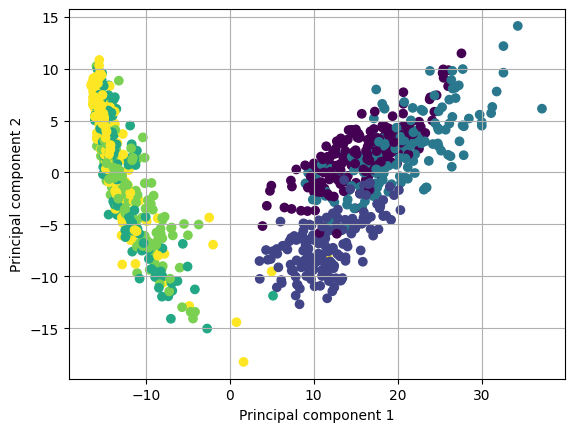

In [61]:
plt.scatter(X_train_pca[:1000, 0], X_train_pca[:1000, 1], c=y_train[:1000])
plt.grid()
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")

Text(0, 0.5, 'Principal component 5')

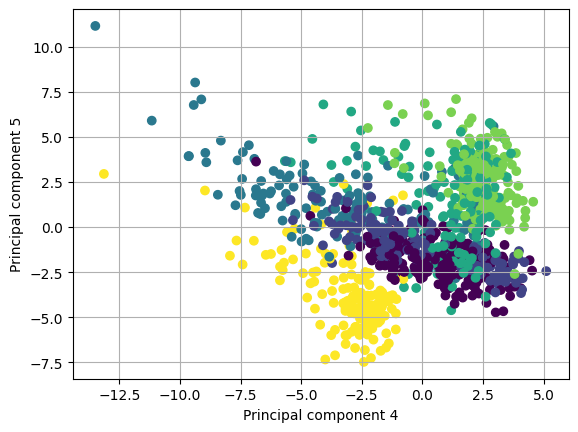

In [62]:
plt.scatter(X_train_pca[:1000, 3], X_train_pca[:1000, 4], c=y_train[:1000])
plt.grid()
plt.xlabel("Principal component 4")
plt.ylabel("Principal component 5")

### Alternative dataset: Wine quality

Please, take this dataset if you are sure you can preprocess it yourself and ready to work with it's features and results, so it is done on your risk.

However you will have interpretable features which can be analysed with shap in last part

In [63]:
# !pip install ucimlrepo

In [64]:
# import ucimlrepo as uci

In [65]:
# dataset = uci.fetch_ucirepo(id=186)
#
# print(dataset.metadata.name, '\n')
# print(dataset.metadata.abstract, '\n')
# print(dataset.metadata.additional_info.summary, '\n')

## Part 1. Fit the model.

Despite optimal parameters (e.g. for xgboost) can be found on the web, we still want you to approximate them by yourself.

In this part just check some (3-5) sets of hyperparameters by hand.

In [66]:
# Example: https://rpubs.com/burakh/har_xgb

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# https://stackoverflow.com/questions/71996617/invalid-classes-inferred-from-unique-values-of-y-expected-0-1-2-3-4-5-got
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)

bsts = [
        XGBClassifier(booster="gbtree", eval_metric="mlogloss", objective='multi:softprob', eta=0.5, max_depth=2, 
                      gamma=0, min_child_weight=0, colsample_bytree=0.2, subsample=1),
        XGBClassifier(booster="gbtree", eval_metric="mae", objective='multi:softmax', eta=0.5, max_depth=2, 
                      gamma=0, min_child_weight=0, colsample_bytree=0.2, subsample=1),
        XGBClassifier(booster="gbtree", eval_metric="mae", objective='multi:softmax', eta=0.5, max_depth=3, 
                      gamma=0, min_child_weight=0, colsample_bytree=0.2, subsample=1),
        XGBClassifier(booster="gbtree", eval_metric="mae", objective='multi:softmax', eta=0.5, max_depth=2, 
                      gamma=0.2, min_child_weight=0, colsample_bytree=0.2, subsample=1),
]

for bst in bsts:
    bst.fit(X_train_pca, y_train)

    y_pred = bst.predict(X_test_pca)

    y_test = le.fit_transform(y_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    # print("Classification Report:\n", classification_report(y_test, y_pred))
    # print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9277231082456736
Accuracy: 0.9277231082456736
Accuracy: 0.9338310145911096
Accuracy: 0.9256871394638616


## Part 2. Use hyper parameter tuning system

Use [optuna](https://optuna.org/), [hyperopt](http://hyperopt.github.io/hyperopt/) or any other zero order optimizer to find optimal hyper param set.

In [67]:
import optuna

def objective(trial):
    param = {
        'objective': trial.suggest_categorical('objective', ['multi:softprob', 'multi:softmax']), 
        'eval_metric': trial.suggest_categorical('eval_metric', ['mlogloss', 'mae', 'mape']), 
        'max_depth': trial.suggest_int('max_depth', 2, 3),
        'gamma': trial.suggest_float('gamma', 0.001, 1, log=True),
        'eta': trial.suggest_float('eta', 0.5, 1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 0.5),
    }

    model = xgb.XGBClassifier(**param)
    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)

    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("Best Parameters:", study.best_params)
print("Best Accuracy:", study.best_value)

[I 2024-11-14 20:30:48,004] A new study created in memory with name: no-name-ee0997e1-c0a9-444a-9594-2d8d279a04dc
[I 2024-11-14 20:30:51,182] Trial 0 finished with value: 0.9297590770274856 and parameters: {'objective': 'multi:softmax', 'eval_metric': 'mae', 'max_depth': 3, 'gamma': 0.14152281379040685, 'eta': 0.6954786245538112, 'subsample': 0.8043065898136308, 'colsample_bytree': 0.30196541485139233}. Best is trial 0 with value: 0.9297590770274856.
[I 2024-11-14 20:30:53,335] Trial 1 finished with value: 0.9273837801153716 and parameters: {'objective': 'multi:softmax', 'eval_metric': 'mlogloss', 'max_depth': 2, 'gamma': 0.07623960778366416, 'eta': 0.5576500334432186, 'subsample': 0.8549013537109076, 'colsample_bytree': 0.26215602249381637}. Best is trial 0 with value: 0.9297590770274856.
[I 2024-11-14 20:30:57,117] Trial 2 finished with value: 0.9300984051577876 and parameters: {'objective': 'multi:softprob', 'eval_metric': 'mae', 'max_depth': 3, 'gamma': 0.02349064032495841, 'eta': 

Best Parameters: {'objective': 'multi:softmax', 'eval_metric': 'mlogloss', 'max_depth': 3, 'gamma': 0.0014224147387581472, 'eta': 0.6856250809111776, 'subsample': 0.8048402440868689, 'colsample_bytree': 0.488480378611707}
Best Accuracy: 0.9358669833729216


### Conclusion

Using Optuna to tune hyperparameters gives insight into which hyperparameters are most important to model performance.  
It is difficult to identify strong patterns, as the results are quite similar and fluctuate between $0.915$ and $0.935$.  
Comparing the runs it can be assumed that the `gamma` value plays a significant role and the result is better with small `gamma`. `gamma` specifies the minimum number of losses to make a further partition on a leaf node of the tree. That is, by increasing `gamma` we make the algorithm more conservative and it can affect.

## Part 3. Interpret the model predictions

Please use [shap](https://github.com/slundberg/shap) to build some plots and try to interpret them.

Analysis for activity:  WALKING


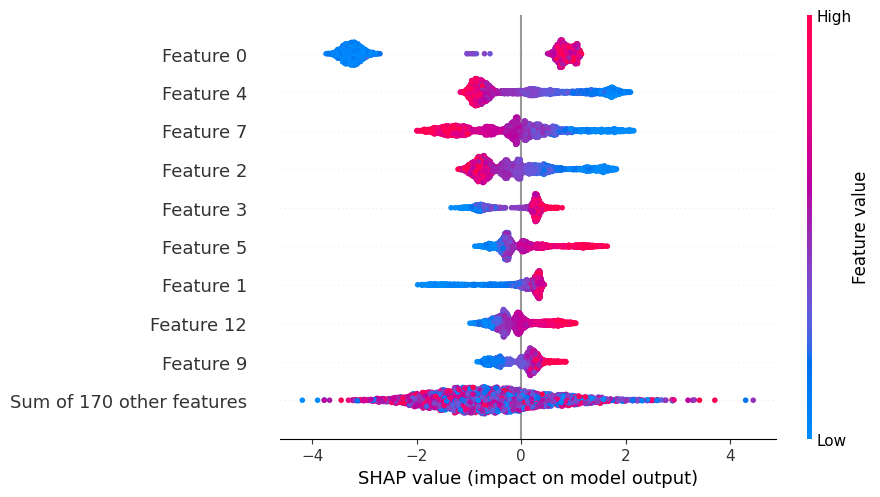

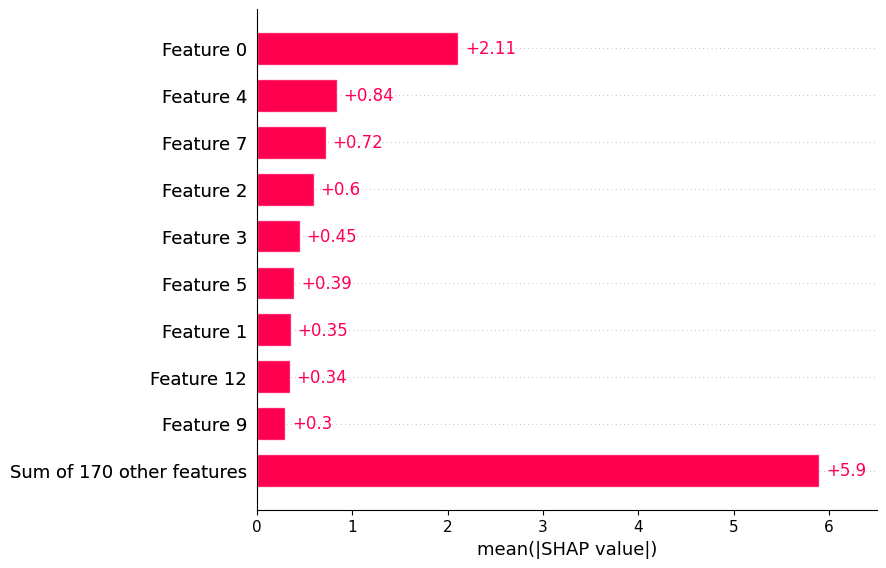

Analysis for activity:  WALKING_UPSTAIRS


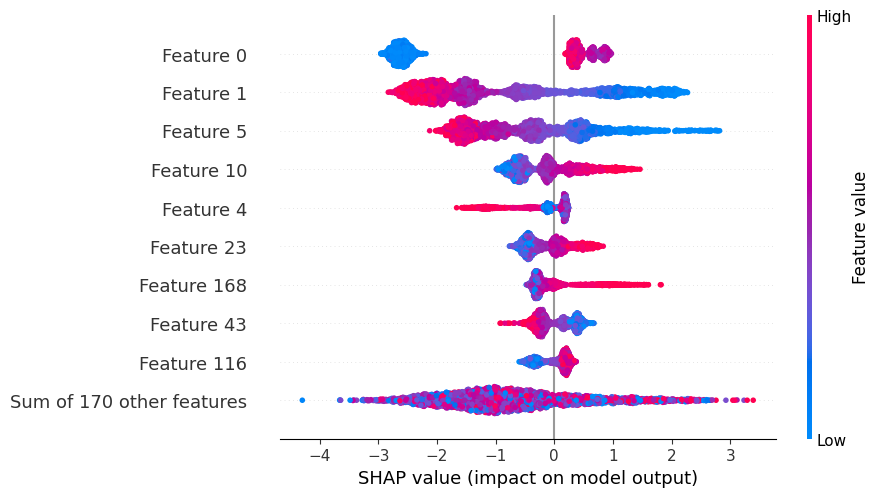

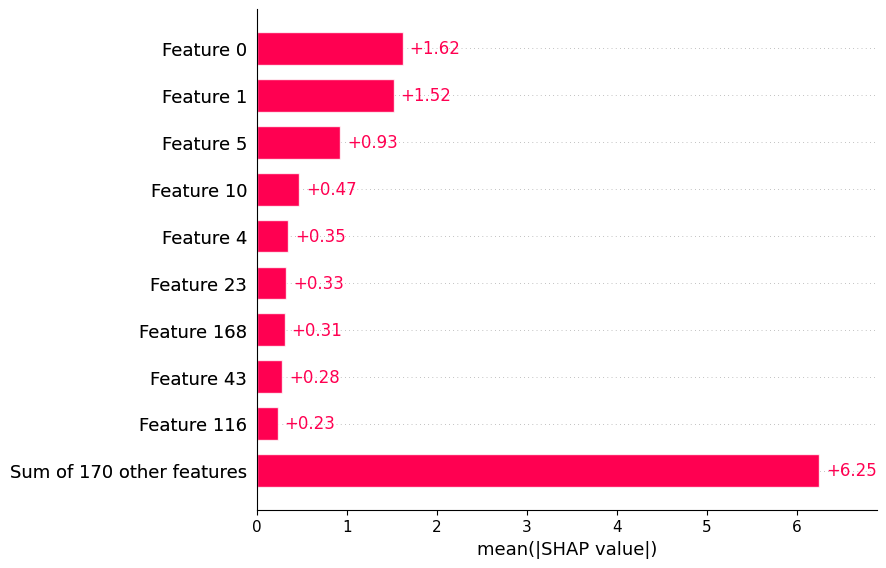

Analysis for activity:  WALKING_DOWNSTAIRS


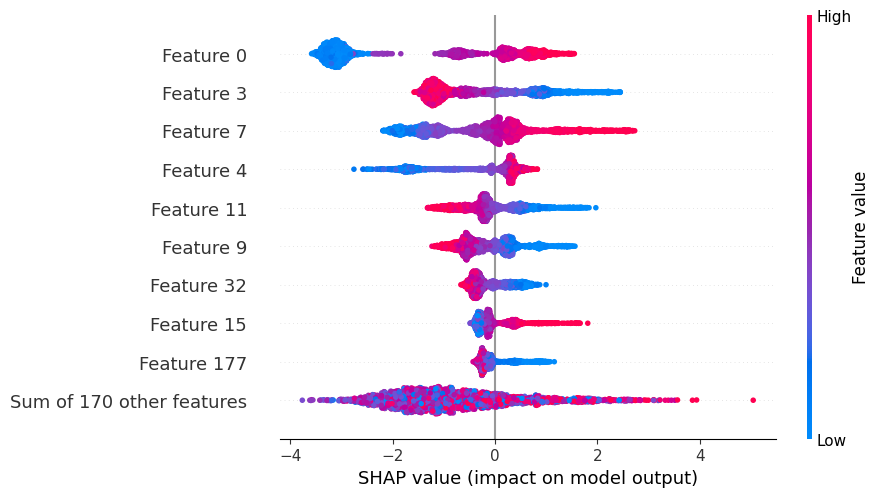

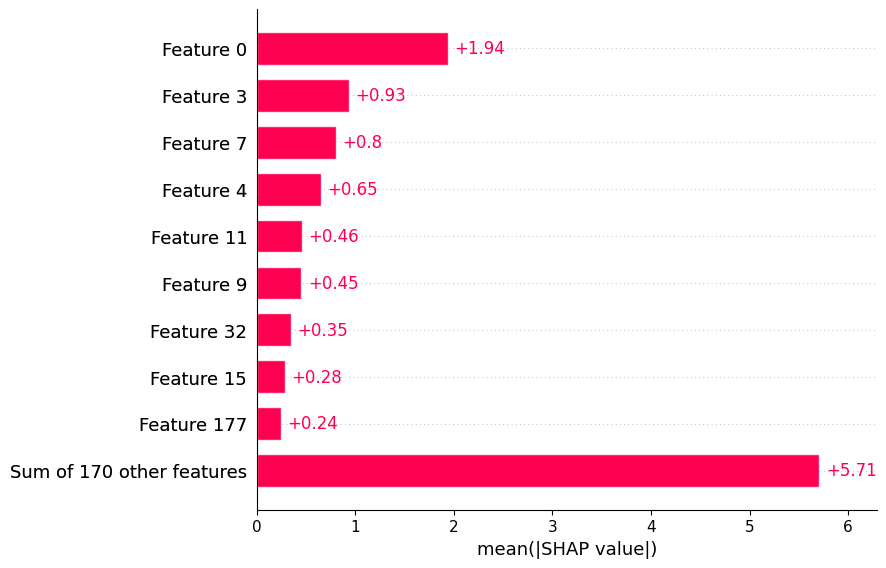

Analysis for activity:  SITTING


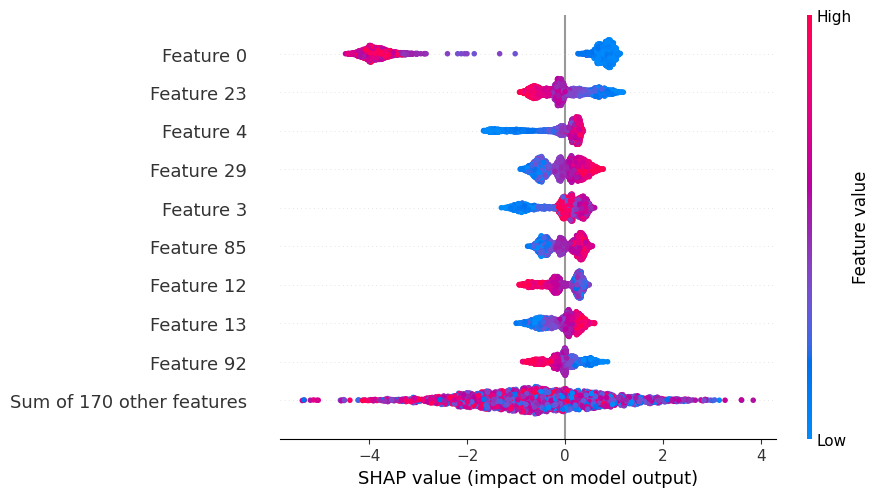

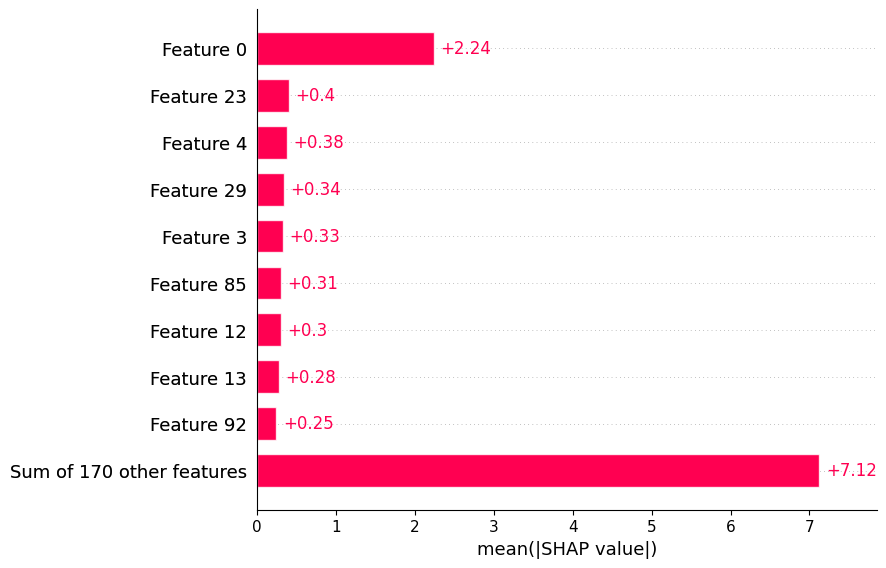

Analysis for activity:  STANDING


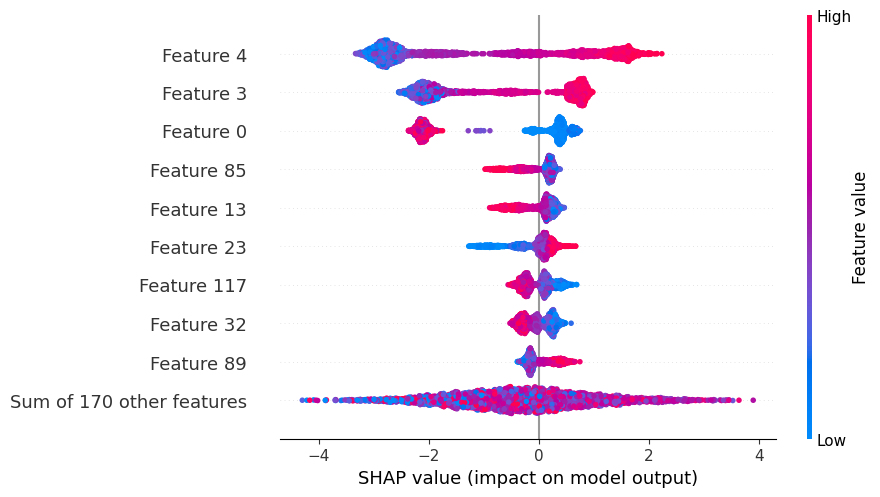

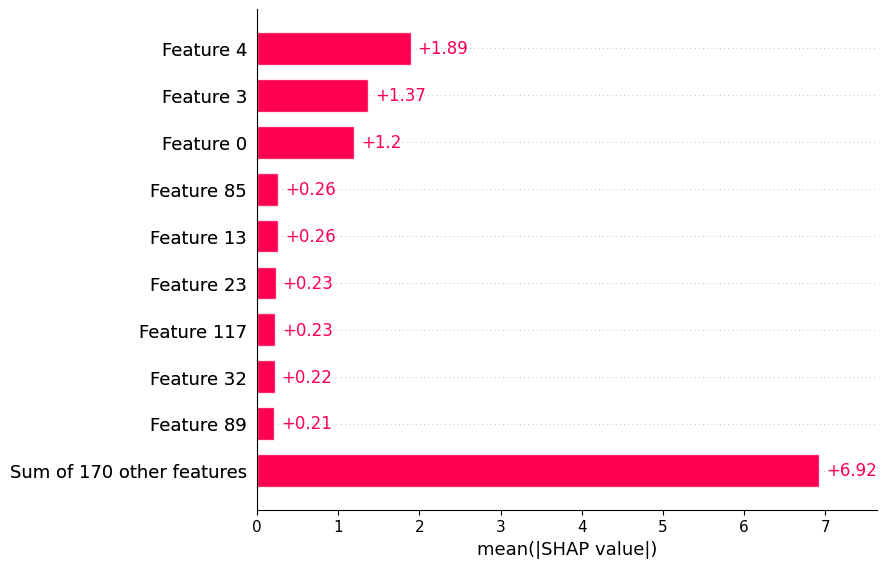

Analysis for activity:  LAYING


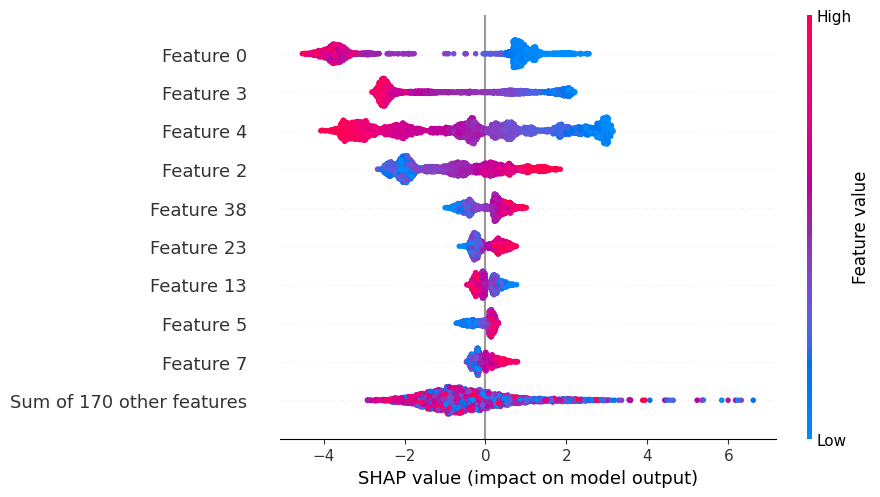

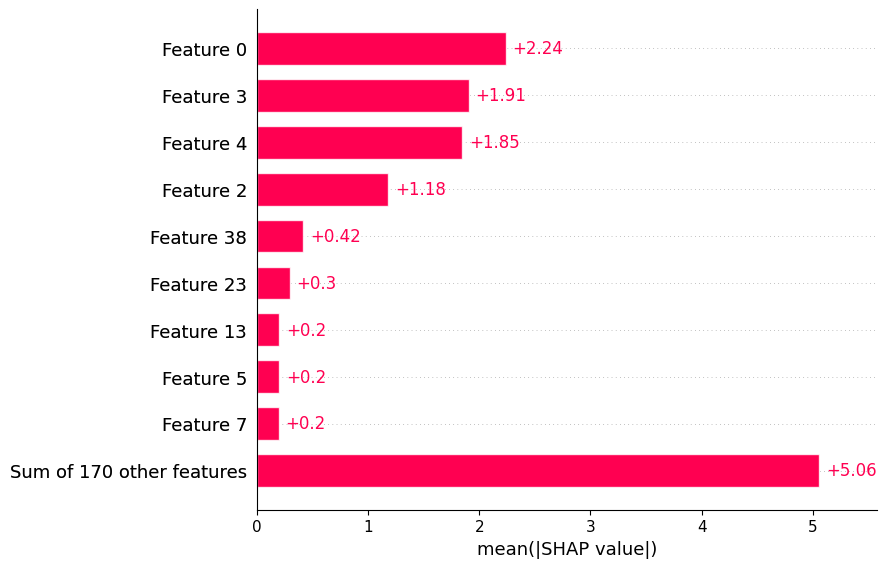

In [ ]:
import shap
bst = XGBClassifier(booster="gbtree", eval_metric="mae", objective='multi:softprob', eta=0.5, max_depth=3, 
                    gamma=0, min_child_weight=0, colsample_bytree=0.2, subsample=1)

y_test = le.fit_transform(y_test)
bst.fit(X_train_pca, y_train)
# y_pred = bst.predict(X_test)

# shap_values = shap.TreeExplainer(bst).shap_values(X_test_pca)
explainer = shap.TreeExplainer(bst)
shap_values = explainer(X_test_pca)
# shap.summary_plot(shap_values, X_train_pca)

# shap.force_plot(explainer.expected_value[0], shap_values[..., 0], X_test_pca[0,:])
for output in range(shap_values.shape[2]):
    print("Analysis for activity: ", activity_labels[output + 1])
    shap.plots.beeswarm(shap_values[:, :, output])
    shap.plots.bar(shap_values[:, :, output])

In [81]:
# for output in range(shap_values.shape[2]):
#     print("Analysis for activity: ", activity_labels[output + 1])
    # shap.summary_plot(shap_values[:, :, output], X_test_pca, plot_type="dot", max_display=5)
    # shap.summary_plot(shap_values[:, :, output], X_test_pca, plot_type="bar", max_display=5)



### Conclusion

With the following charts, we can see which features are most reflective of activity.  

We can see that 10 features contribute as much as the other 170. In this way we can identify the core set of features, and do a deeper analysis among the core features.  

As a result, we can see that for all activities, except `STANDING`, `feature 0` has the most influence (It is also significant for `STANDING` as well).  
In addition to `feature 0` there are `features 3`, `feature2`, `feature 4` (especially for `STANDING`) that have a strong impact.